In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /home/arash/HVD_SDF
Test Step files Directory: /home/arash/HVD_SDF/Testparts
device: cuda
PyVista backend: trame



=== Active Face Info ===
XYZ bounds:
  X: [-28620.000000, 1380.000000]  span=30000.000000
  Y: [-29364.187386, 30635.812615]  span=60000.000000
  Z: [-1170.999105, -78.999105]  span=1092.000000

UV bounds:
  U: [85201.950261, 93125.321960]
  V: [-0.000000, 1167.041628]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:39485/index.html?ui=P_0x780d000934f0_0&reconnect=auto" class="pyvi…

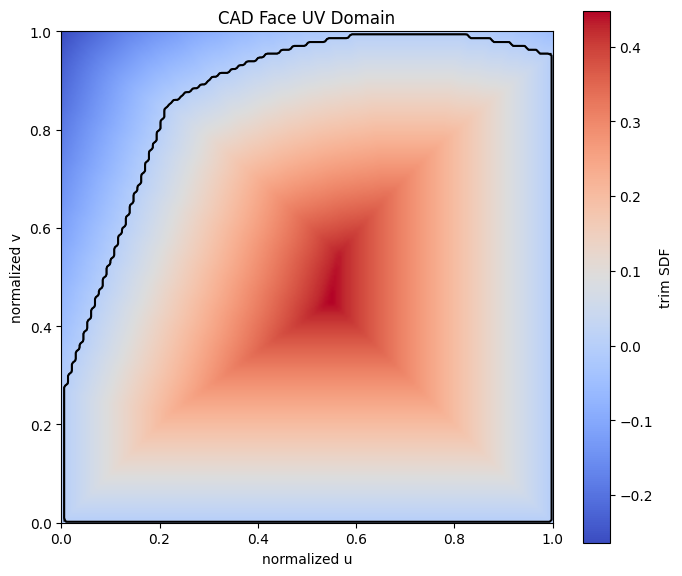

In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = YachtBodypart

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=128,
)
domain = Face_Cad.generate_from_file(shape_path)
Face_Cad.print_face_info()
viz = CADDomainVisualizer(Face_Cad)
viz.plot_uv_domain()
viz.show_3d(res_u=200, res_v=200, show_edges=True)


In [3]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)

In [4]:
seeds = torch.tensor(
    [
        [0.2, 0.2],
        [0.8, 0.2],
        [0.5, 0.8],
    ],
    dtype=torch.float32,
    requires_grad=True,
)

out = dec(seeds)

print("Vertices")
print(out["vertices_uv"])

print("\nAlpha")
print(out["alpha"])

print("\nTriples")
print(out["triple_idx"])

Vertices
tensor([[0.5000, 0.4250]], grad_fn=<NanToNumBackward0>)

Alpha
tensor([1.], grad_fn=<ClampBackward1>)

Triples
tensor([[0, 1, 2]])


In [5]:
loss = (out["vertices_uv"] * out["alpha"][:, None]).sum()

loss.backward()

print(seeds.grad)

tensor([[ 7.5000e-01,  5.6250e-01],
        [ 2.5000e-01, -1.8750e-01],
        [ 4.1723e-07,  6.2500e-01]])


In [6]:
torch.isfinite(seeds.grad).all()

tensor(True)

In [7]:
seeds = torch.tensor(
    [
        [0.2,0.2],
        [0.5,0.2],
        [0.8,0.2],
    ],
    dtype=torch.float32,
)

out = dec(seeds)

print(out["alpha"])
print(out["validity"]["area"])

tensor([3.0886e-06])
tensor([4.5398e-05])


In [8]:
seeds = torch.tensor(
    [
        [0.2,0.2],
        [0.2001,0.2],
        [0.8,0.8],
    ],
    dtype=torch.float32,
)

out = dec(seeds)

print(out["alpha"])
print(out["validity"]["close"])

tensor([4.3257e-09])
tensor([5.2294e-05])


In [9]:
seeds = torch.tensor(
    [
        [0.2,0.2],
        [0.8,0.2],
        [0.8,0.8],
        [0.2,0.8],
    ],
    dtype=torch.float32,
)

out = dec(seeds)

print(out["vertices_uv"])
print(out["alpha"])

tensor([[0.5000, 0.5000],
        [0.5000, 0.5000],
        [0.5000, 0.5000],
        [0.5000, 0.5000]])
tensor([0.3776, 0.3776, 0.3776, 0.3775])


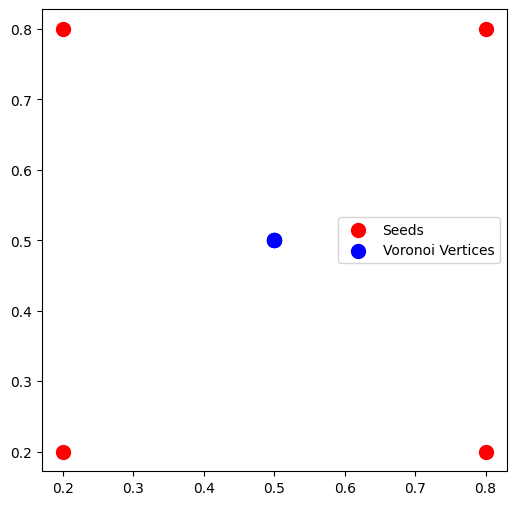

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    seeds[:,0],
    seeds[:,1],
    c="red",
    s=100,
    label="Seeds"
)

plt.scatter(
    out["vertices_uv"][:,0].detach(),
    out["vertices_uv"][:,1].detach(),
    c="blue",
    s=100,
    label="Voronoi Vertices"
)

plt.xlim(0,1)
plt.ylim(0,1)
plt.axis("equal")
plt.legend()
plt.show()

In [11]:
print(out["vertices_uv"])
print(out["triple_idx"])
print(out["alpha"])

tensor([[0.5000, 0.5000],
        [0.5000, 0.5000],
        [0.5000, 0.5000],
        [0.5000, 0.5000]])
tensor([[0, 1, 2],
        [0, 1, 3],
        [0, 2, 3],
        [1, 2, 3]])
tensor([0.3776, 0.3776, 0.3776, 0.3775])


In [12]:
S = 20

seeds = torch.rand(
    S,
    2,
    requires_grad=True,
)

out = dec(seeds)

print(out["vertices_uv"].shape)
print(out["alpha"].shape)
print(out["alpha"].min())
print(out["alpha"].max())
print(out["alpha"].mean())

torch.Size([1140, 2])
torch.Size([1140])
tensor(0., grad_fn=<MinBackward1>)
tensor(1.0000, grad_fn=<MaxBackward1>)
tensor(0.0190, grad_fn=<MeanBackward0>)


In [13]:
loss = out["alpha"].sum()
loss.backward()
print(torch.isfinite(seeds.grad).all())

tensor(True)


In [14]:
import torch
import matplotlib.pyplot as plt

S = 20

S = 10

seeds = torch.tensor([
    [0.15, 0.15],
    [0.50, 0.12],
    [0.85, 0.18],
    [0.22, 0.45],
    [0.72, 0.42],
    [0.12, 0.78],
    [0.42, 0.72],
    [0.82, 0.76],
    [0.58, 0.55],
    [0.35, 0.30],
], dtype=torch.float32)

out = dec(
    seeds,
    cad_domain=Face_Cad,   # optional; remove if testing only UV
    u_periodic=domain["u_periodic"],
    v_periodic=domain["v_periodic"],
    return_xyz=False,
)

vertices = out["vertices_uv"].detach()
alpha = out["alpha"].detach()

print(vertices.shape, alpha.shape)
print(alpha.min(), alpha.max(), alpha.mean())

torch.Size([120, 2]) torch.Size([120])
tensor(0.) tensor(1.) tensor(0.0825)


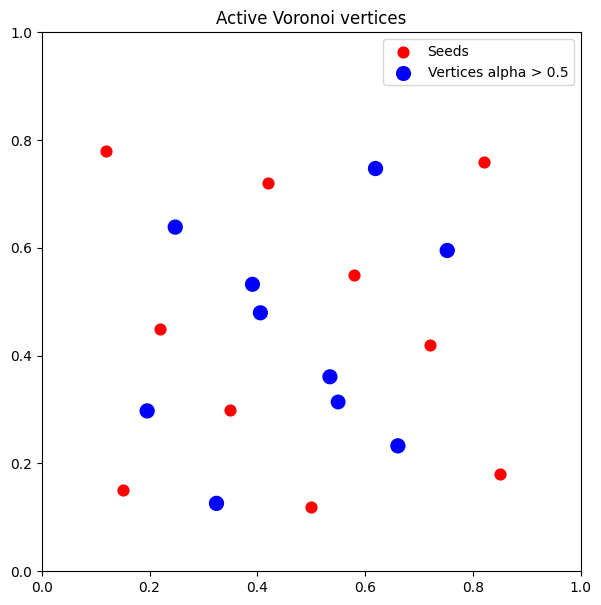

active vertices: 10


In [25]:
thr = 0.5
keep = alpha > thr

plt.figure(figsize=(7, 7))

plt.scatter(
    seeds[:, 0],
    seeds[:, 1],
    c="red",
    s=60,
    label="Seeds",
)

plt.scatter(
    vertices[keep, 0],
    vertices[keep, 1],
    c="blue",
    s=100 * alpha[keep],
    label=f"Vertices alpha > {thr}",
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal")
plt.legend()
plt.title("Active Voronoi vertices")
plt.show()

print("active vertices:", keep.sum().item())

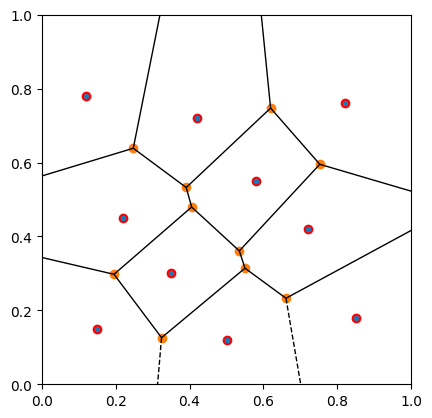

In [27]:
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt

points = seeds.detach().cpu().numpy()  # shape [S,2]

vor = Voronoi(points)

# print("Voronoi vertices:")
# print(vor.vertices)

# print("Regions:")
# print(vor.regions)

# print("Ridge points:")
# print(vor.ridge_points)

# print("Ridge vertices:")
# print(vor.ridge_vertices)

fig = voronoi_plot_2d(vor)
plt.scatter(points[:,0], points[:,1], c="red")
plt.xlim(0,1)
plt.ylim(0,1)
plt.gca().set_aspect("equal")
plt.show()